YOLO model loaded successfully!

image 1/1 C:\Users\Localws\images\image1.jpg: 480x640 1 book, 782.9ms
Speed: 16.9ms preprocess, 782.9ms inference, 10.1ms postprocess per image at shape (1, 3, 480, 640)

Image: image1.jpg
book : 0.69


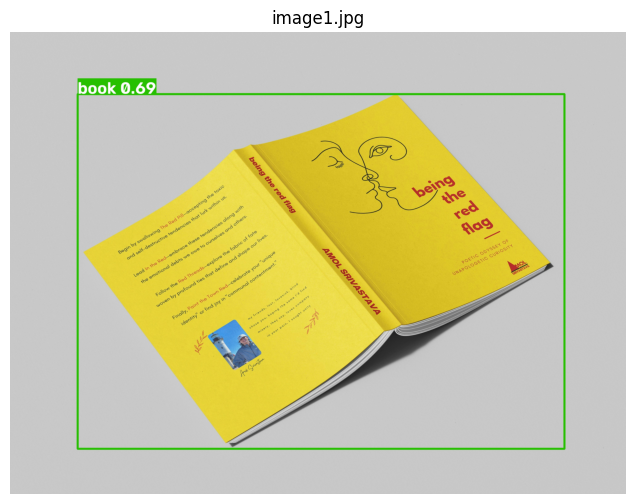


image 1/1 C:\Users\Localws\images\image10.jpg: 416x640 1 potted plant, 1 laptop, 1 vase, 555.9ms
Speed: 16.4ms preprocess, 555.9ms inference, 8.3ms postprocess per image at shape (1, 3, 416, 640)

Image: image10.jpg
laptop : 0.93
vase : 0.84
potted plant : 0.63


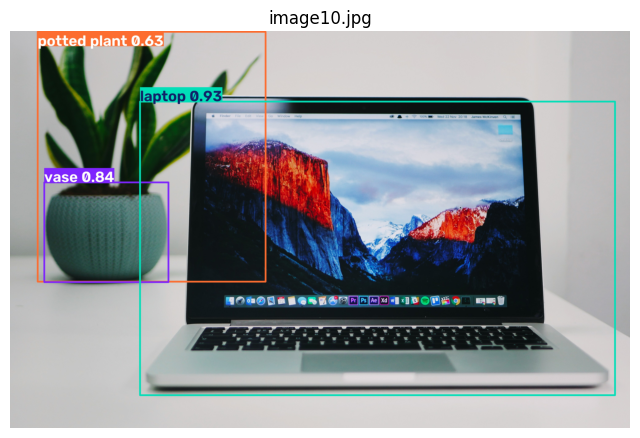


image 1/1 C:\Users\Localws\images\image2.jpg: 640x480 1 bicycle, 621.4ms
Speed: 16.6ms preprocess, 621.4ms inference, 5.3ms postprocess per image at shape (1, 3, 640, 480)

Image: image2.jpg
bicycle : 0.91


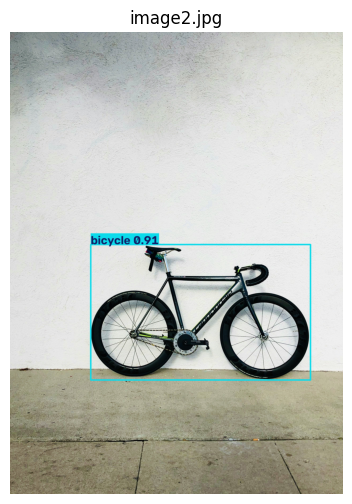


image 1/1 C:\Users\Localws\images\image3.jpg: 448x640 2 laptops, 566.1ms
Speed: 15.1ms preprocess, 566.1ms inference, 5.9ms postprocess per image at shape (1, 3, 448, 640)

Image: image3.jpg
laptop : 0.75
laptop : 0.72


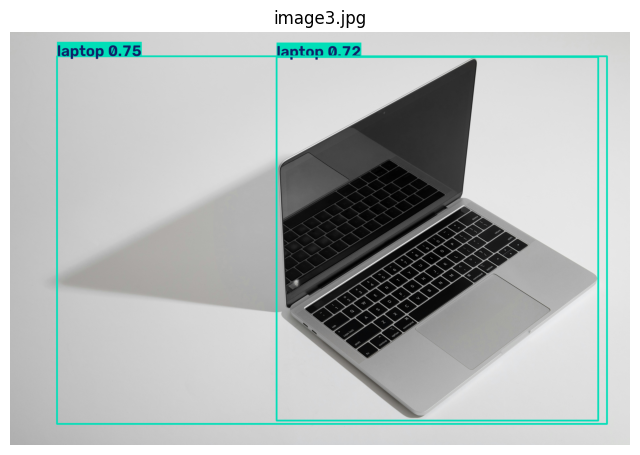


image 1/1 C:\Users\Localws\images\image4.jpg: 512x640 1 bird, 4 kites, 675.8ms
Speed: 16.0ms preprocess, 675.8ms inference, 5.5ms postprocess per image at shape (1, 3, 512, 640)

Image: image4.jpg
kite : 0.58
kite : 0.57
kite : 0.56
kite : 0.54
bird : 0.26


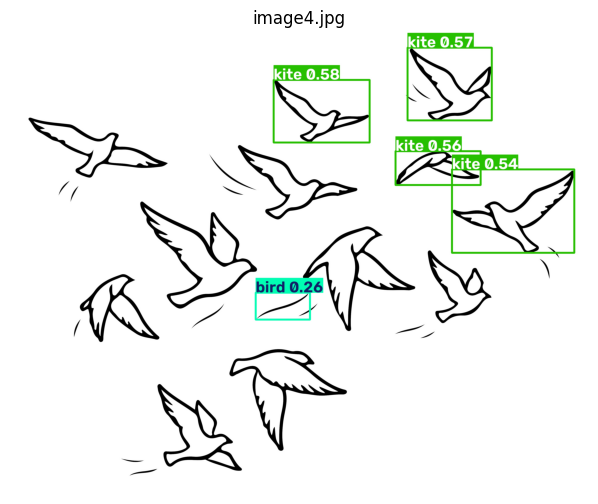


image 1/1 C:\Users\Localws\images\image5.jpg: 640x512 1 chair, 670.2ms
Speed: 16.0ms preprocess, 670.2ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 512)

Image: image5.jpg
chair : 0.81


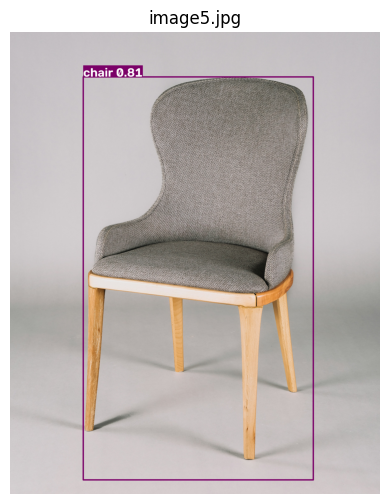


image 1/1 C:\Users\Localws\images\image6.jpg: 640x512 1 vase, 537.7ms
Speed: 16.9ms preprocess, 537.7ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 512)

Image: image6.jpg
vase : 0.79


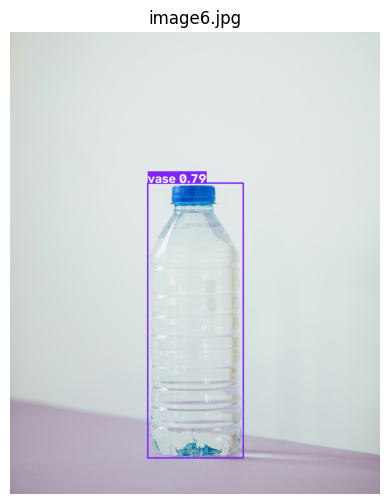


image 1/1 C:\Users\Localws\images\image7.jpg: 448x640 1 bicycle, 484.8ms
Speed: 13.8ms preprocess, 484.8ms inference, 5.4ms postprocess per image at shape (1, 3, 448, 640)

Image: image7.jpg
bicycle : 0.91


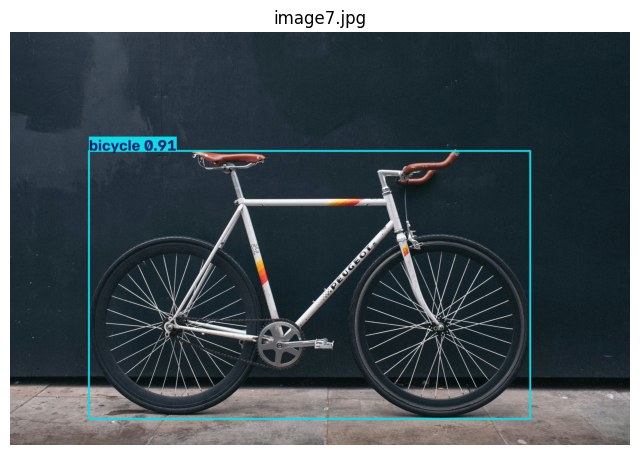


image 1/1 C:\Users\Localws\images\image8.jpg: 448x640 1 car, 467.4ms
Speed: 14.2ms preprocess, 467.4ms inference, 5.6ms postprocess per image at shape (1, 3, 448, 640)

Image: image8.jpg
car : 0.77


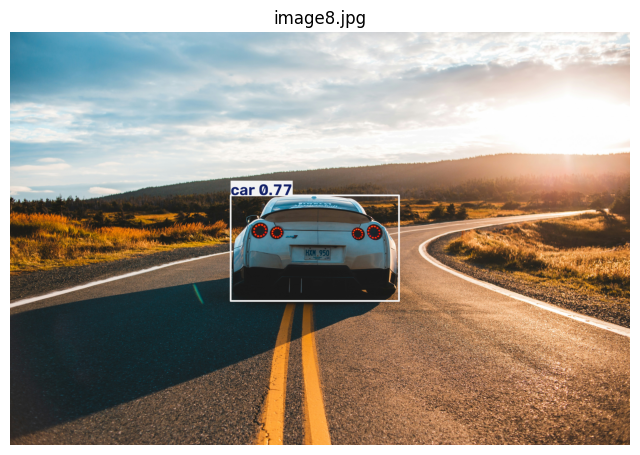


image 1/1 C:\Users\Localws\images\image9.jpg: 384x640 1 toothbrush, 539.1ms
Speed: 18.9ms preprocess, 539.1ms inference, 5.2ms postprocess per image at shape (1, 3, 384, 640)

Image: image9.jpg
toothbrush : 0.30


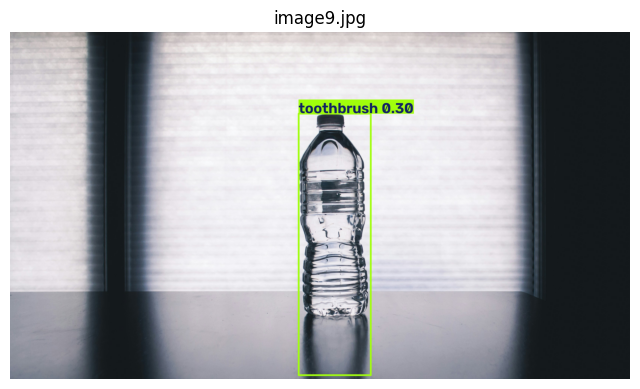


All images processed successfully!

WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/218) C:\Users\Localws\video\video1.mp4: 640x384 2 persons, 1 car, 1 bus, 582.0ms
video 1/1 (frame 2/218) C:\Users\Localws\video\video1.mp4: 640x384 2 persons, 1 car, 1 bus, 489.2ms
video 1/1 (frame 3/218) C:\Users\Localws\video\video1.mp4: 640x384 3 persons, 1 car, 1 bus, 483.6ms
video 1/1 (frame 4/218) C:\Users\Localws\video\video1.mp4: 640x384 3 persons, 1 car, 1 bus, 444.5ms
video 1/1 (frame 5/218) C

In [1]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt

# ==========================
# Load YOLO Model
# ==========================
model = YOLO("yolov8n.pt")

print("YOLO model loaded successfully!")

# ==========================
# Create Output Folders
# ==========================
os.makedirs("outputs/images", exist_ok=True)
os.makedirs("outputs/videos", exist_ok=True)

# ==========================
# Process Images
# ==========================
image_folder = "images"

if not os.path.exists(image_folder):
    print(f"Image folder '{image_folder}' not found.")
else:
    image_files = [
        file for file in os.listdir(image_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(image_files) == 0:
        print("No images found.")

    else:
        for image_name in image_files:

            image_path = os.path.join(image_folder, image_name)

            # Run YOLO Detection
            results = model(image_path)

            # Save Output Image
            save_path = os.path.join("outputs/images", image_name)
            results[0].save(filename=save_path)

            print(f"\nImage: {image_name}")

            if len(results[0].boxes) == 0:
                print("No objects detected.")
            else:
                for box in results[0].boxes:

                    class_id = int(box.cls[0])
                    confidence = float(box.conf[0])

                    print(
                        f"{model.names[class_id]} : {confidence:.2f}"
                    )

            # Display Processed Image
            detected_image = cv2.imread(save_path)
            detected_image = cv2.cvtColor(
                detected_image,
                cv2.COLOR_BGR2RGB
            )

            plt.figure(figsize=(8, 6))
            plt.imshow(detected_image)
            plt.title(image_name)
            plt.axis("off")
            plt.show()

        print("\nAll images processed successfully!")

# ==========================
# Process Videos
# ==========================
video_folder = "video"

if not os.path.exists(video_folder):
    print(f"Video folder '{video_folder}' not found.")
else:
    video_files = [
        file for file in os.listdir(video_folder)
        if file.lower().endswith((".mp4", ".avi", ".mov"))
    ]

    if len(video_files) == 0:
        print("No videos found.")

    else:
        for video in video_files:

            video_path = os.path.join(video_folder, video)

            model.predict(
                source=video_path,
                save=True,
                project="outputs/videos",
                name=os.path.splitext(video)[0],
                exist_ok=True
            )

            print(f"\n{video} processed successfully!")
            print(
                f"Saved in: outputs/videos/{os.path.splitext(video)[0]}"
            )

        print("\nAll videos processed successfully!")